# Chapter 08 - Tree-Based Algorithms and Ensemble Methods
## Decision Trees, Random Forest, and Ensemble Learning
Based on scikit-learn Cookbook. This notebook explains tree models, overfitting control, and ensemble methods.

## Objective
Understand how tree-based models split data, how ensembles improve performance, and how feature importance can be interpreted.

## Theory Introduction
Decision Trees make predictions by recursively splitting data based on feature thresholds. They are intuitive and easy to interpret, but deep trees can overfit.

Ensemble methods such as Random Forest combine many trees to improve stability and predictive performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
plt.style.use('ggplot')

## 1. Load Dataset

In [2]:
data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

Wine dataset contains multiple numeric features and multiclass targets, making it suitable for tree-based classification.

## 2. Train Models

In [3]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
forest = RandomForestClassifier(n_estimators=200, random_state=42)

tree.fit(X_train,y_train)
forest.fit(X_train,y_train)

pred_tree = tree.predict(X_test)
pred_forest = forest.predict(X_test)

acc_tree = accuracy_score(y_test,pred_tree)
acc_forest = accuracy_score(y_test,pred_forest)
print('Decision Tree Accuracy:', round(acc_tree,4))
print('Random Forest Accuracy:', round(acc_forest,4))

Decision Tree Accuracy: 0.9556
Random Forest Accuracy: 1.0


## 3. Accuracy Comparison

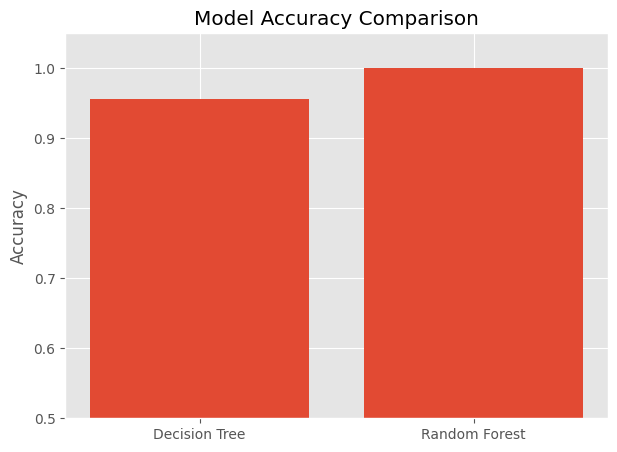

In [4]:
plt.figure(figsize=(7,5))
plt.bar(['Decision Tree','Random Forest'], [acc_tree, acc_forest])
plt.ylim(0.5,1.05)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

**Description:** Random Forest often outperforms a single tree because averaging many trees reduces variance and overfitting.

## 4. Confusion Matrix (Random Forest)

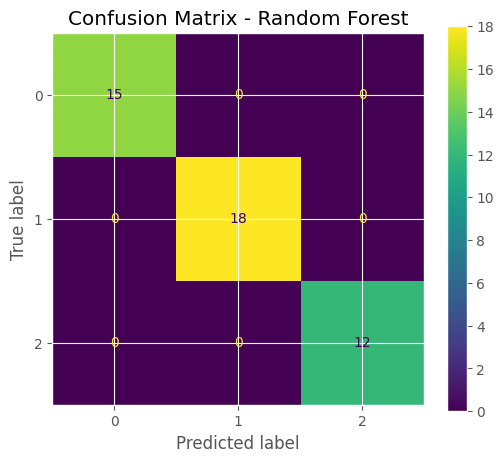

In [5]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test,pred_forest,ax=ax)
plt.title('Confusion Matrix - Random Forest')
plt.show()

**Description:** The confusion matrix summarizes multiclass classification performance.

## 5. Feature Importance

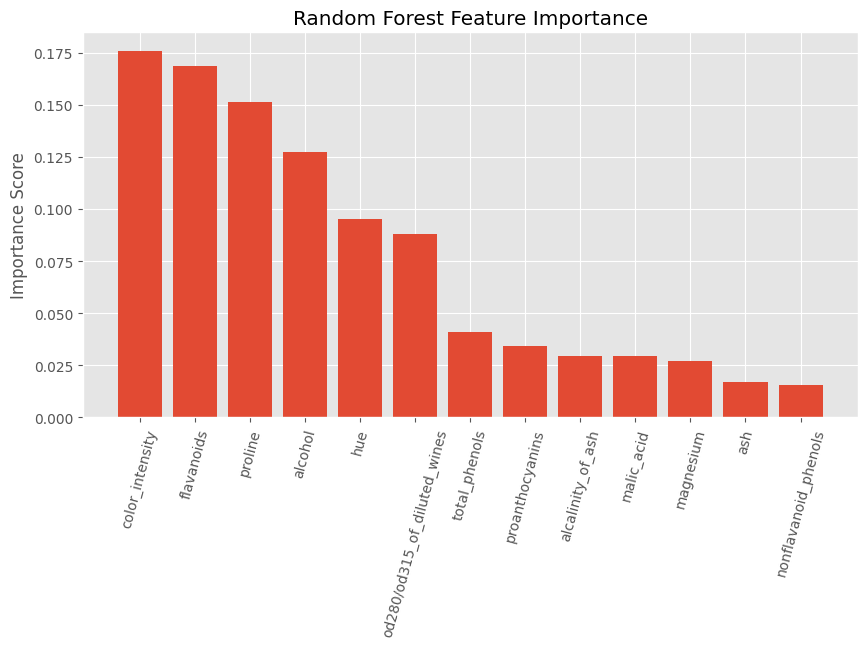

In [6]:
importances = forest.feature_importances_
idx = np.argsort(importances)[::-1]
plt.figure(figsize=(10,5))
plt.bar(np.array(feature_names)[idx], importances[idx])
plt.xticks(rotation=75)
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance Score')
plt.show()

**Description:** Higher importance scores indicate features that contribute more strongly to prediction decisions.

## 6. Tree Depth Experiment

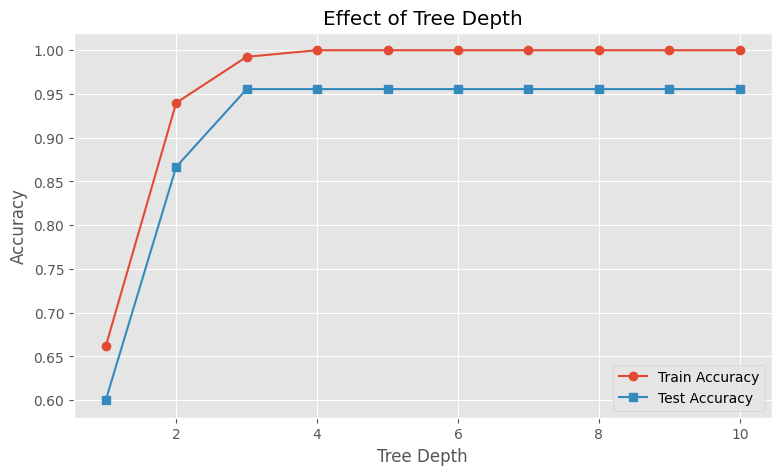

In [7]:
depths = range(1,11)
train_scores = []
test_scores = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train,y_train)
    train_scores.append(m.score(X_train,y_train))
    test_scores.append(m.score(X_test,y_test))

plt.figure(figsize=(9,5))
plt.plot(list(depths), train_scores, marker='o', label='Train Accuracy')
plt.plot(list(depths), test_scores, marker='s', label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Effect of Tree Depth')
plt.legend()
plt.show()

**Description:** Increasing depth may improve training accuracy but can eventually reduce test performance due to overfitting.

## Important Theory Concepts
- **Gini / Entropy:** Measures node impurity.
- **Max Depth:** Controls tree complexity.
- **Bagging:** Bootstrap sampling used in Random Forest.
- **Feature Randomness:** Different features considered at splits.
- **Variance Reduction:** Averaging many trees improves stability.

## Interpretation of Results
Single trees are easy to explain, but ensembles often provide better generalization. Feature importance also offers useful business insights.

## Summary
Tree-based algorithms are versatile, require little preprocessing, and can model non-linear relationships. Random Forest is one of the strongest baseline models in many real-world tasks.

## Conclusion
Use Decision Trees for interpretability and Random Forest when higher predictive accuracy and robustness are needed.